# Evaluating Classifiers

### Overview

For each step, read the explanation, then **run the code cell(s)** right below it.

You will practice how to:

- Train different Decision Tree models
- Generate predictions on test data
- Create a confusion matrix
- Calculate and compare different evaluation metrics
- Utilize `GridSearchCV` to perform an exhaustive search for optimal model paramaters
- Compare different model results


#### Import libraries


In [1]:
import os
import sys
from pathlib import Path
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, fbeta_score

# Set random seed variable for code reproducibility
SEED = 1


In [2]:
# Import local libraries
root_dir = Path.cwd().resolve().parents[0]
sys.path.append(str(root_dir))

# Visualization functions
from src.visuals.make_plots import *

# Helper functions
from src.utils.helpers import *

# Load the "autoreload" extension so that code can change
%load_ext autoreload
#%reload_ext autoreload

# Always reload modules so that as you change code in src, it gets loaded
%autoreload 2

### Prepare Data

**Create a dataframe for the `UniversalBank.csv` data**

In the next cell, we load the dataset from a `.csv` file into a pandas DataFrame so we can explore it and prepare for modeling and evaluation.


In [3]:
bank_df = pd.read_csv(os.path.join('..','data','UniversalBank.csv'))
bank_df.columns = [c.replace(' ', '_') for c in bank_df.columns]

bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP_Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [4]:
bank_df.head()

,ID,Age,Experience,Income,ZIP_Code,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


**Create `X` dataframe for the predictors and `y` for the target variable**

For this tutorial, we only use the binary predictor variables:

* `Income`
* `CCAvg`
* `Securities_Account`
* `CD_Account`
* `Online`
* `CreditCard`

The target variable is whether the customer accepted the personal loan offer:

- `Personal_Loan`



In [5]:
X = bank_df[['Income', 'CCAvg', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']]
y = bank_df['Personal_Loan']

print('Features:', X.shape)
print('Target:', y.shape)

Features: (5000, 6)
Target: (5000,)


**Split dataset into training and test sets**

Next, we partition the data into a **training set (70%)** and a **test set (30%)**.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=SEED)

print('Training Set:', X_train.shape)
print('Test Set:', X_test.shape)

Training Set: (3500, 6)
Test Set: (1500, 6)


### Evaluate Models

**Create a simple decision tree with a `max_depth` of 2.**

For **Model 1**, we will create a simple `DecisionTreeClassifier` using all default parameters except `max_depth`.


In [7]:
dt1 = DecisionTreeClassifier(max_depth=2, random_state=SEED)

dt1.fit(X_train, y_train)

dt1

DecisionTreeClassifier(max_depth=2, random_state=1)

**Create a confusion matrix for Model 1**

Now, let's visualize the confusion matrix using the test partition.


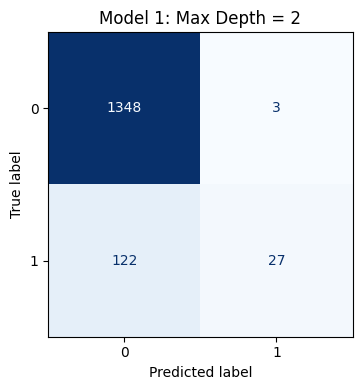

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
title1 = 'Model 1: Max Depth = 2'
plot_confusion_matrix(dt1, X_test, y_test, ax, title1)

**Display evaluation metrics for Model 1**

For this tutorial, we will display a variety of evaluation metrics including:

- Accuracy
- Precision
- Recall
- F2 Score

Make predictions on `X_test` and display each metric.

**A simple helper `evaluate_model` function is used for this tutorial to minimize repeating code for each model.**

For `precision_score`, `recall_score`, and `fbeta_score` in `sklearn.metrics`, the default value for `pos_label` is 1. Since we are interested in the predictions for the positive class, we will not change that default. However, if you were interested in showing the evaluation metrics for other class labels, you would change that parameter such as `0`.


In [9]:
pred1 = dt1.predict(X_test)

dt1_metrics = evaluate_model(y_test, pred1, title1)

Model 1: Max Depth = 2
Accuracy: 0.9167
Precision: 0.9000
Recall: 0.1812
F1: 0.3017


**Create a decision tree with a `max_depth` of 5 and `min_samples_leaf` of 50.**

For **Model 2**, we will increase the depth of the tree to 5 and use `min_samples_leaf` for early stopping to enforce a minimum number of samples at the leaf nodes. This model allows the decision tree to grow deeper but prevents splits that create very small leaf nodes.


In [10]:
dt2 = DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=SEED)

dt2.fit(X_train, y_train)

dt2

DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=1)

**Create a confusion matrix for Model 2**

Now, let's visualize the confusion matrix using the test partition.


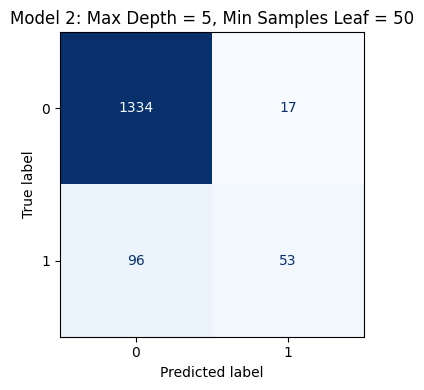

In [11]:
fig, ax = plt.subplots(figsize=(4, 4))
title2 = 'Model 2: Max Depth = 5, Min Samples Leaf = 50'
plot_confusion_matrix(dt2, X_test, y_test, ax, title2)

**Display evaluation metrics for Model 2**

Create predictions and display the evaluation metrics for Model 2.


In [12]:
pred2 = dt2.predict(X_test)

dt2_metrics = evaluate_model(y_test, pred2, title2)

Model 2: Max Depth = 5, Min Samples Leaf = 50
Accuracy: 0.9247
Precision: 0.7571
Recall: 0.3557
F1: 0.4840


**Create a decision tree with optimal values for `max_depth` and `min_samples_leaf`.**

For **Model 3**, instead of manually selecting a parameter value and see how it performs on the test partition, we can use **GridSearchCV** to search for the optimal value using cross validation on the training parition.

For this bank, the missed opportunity cost for not opening a new personal loan for the customer is much higher than the false alarm cost. Therefore, we will optimize based on `recall` to build a model that capture the most of the true positive class using `k = 5` cross-validation



In [13]:
dt3_base = DecisionTreeClassifier(random_state=SEED)

# Define the parameter grid
param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_leaf': [1,5,10,25,50]
}

# Set up GridSearchCV
grid_search = GridSearchCV(dt3_base, param_grid, cv=5, scoring='recall', n_jobs=-1)

# Fit the model to training data (assuming X_train, y_train are defined)
grid_search.fit(X_train, y_train)

dt3 = grid_search.best_estimator_

dt3

DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=1)

### Key GridSearchCV Parameters
Below we will discuss **some** of the key parameters for `GridSearchCV` that control how hyperparameter tuning is performed and how the best model is selected. Check out the [API Reference](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) for the full list of parameters.

**`estimator`** 
The machine learning model that we want to optimize.

Example in this tutorial:

```python
DecisionTreeClassifier()
````

Grid search will train many versions of this model using different combinations of parameter values.

**`param_grid`** 
Dictionary that defines the hyperparameters and values to test.

GridSearchCV tests every possible combination of these values.

**`scoring`** 
Determines the metric used to evaluate and select the best model.

Examples:

```
"accuracy"
"precision"
"recall"
"f1"
```
See the [scoring string names](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names) for a full list. You can also use a custom scorer that returns a single value.

**cv** 
Number of cross-validation folds used to evaluate each parameter combination.

Example:

```
cv = 5
```

The training data is split into 5 folds. The model is trained and validated 5 times, each time using a different fold for validation. This produces a more reliable estimate of model performance.

**`refit`** 
Determines whether the model with the best parameters is retrained on the full training dataset.

```
True (default)
```

This allows the best model to be used directly for predictions after grid search completes.

**`n_jobs`** 
Controls how many CPU cores are used during grid search.

```
None → use one processor
-1 → use all available processors
```

Using `-1` can significantly speed up grid search when testing many parameter combinations.

**`best_params_`** 
Attribute that returns the parameter combination that produced the best cross-validation performance.

Example:

```python
grid.best_params_
```

**`best_estimator_`** 
Attribute that returns the fully trained model using the best parameter combination.

Example:

```python
best_tree = grid.best_estimator_
```

This model can then be used to make predictions on the test dataset.

In [14]:
# Print the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score on the Training Partition: {grid_search.best_score_:.4f}")

Best Parameters: {'max_depth': 6, 'min_samples_leaf': 10}
Best Score on the Training Partition: 0.4469


**Create a confusion matrix for Model 3**

Now, let's visualize the confusion matrix using the test partition.


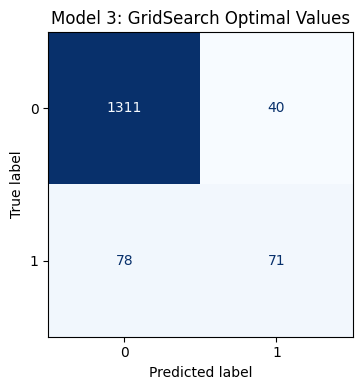

In [15]:
fig, ax = plt.subplots(figsize=(4, 4))
title3 = 'Model 3: GridSearch Optimal Values'
plot_confusion_matrix(dt3, X_test, y_test, ax, title3)

**Display evaluation metrics for Model 3**

Create predictions and display the evaluation metrics for Model 3.


In [16]:
pred3 = dt3.predict(X_test)

dt3_metrics = evaluate_model(y_test, pred3, title3)

Model 3: GridSearch Optimal Values
Accuracy: 0.9213
Precision: 0.6396
Recall: 0.4765
F1: 0.5462


### Model Comparison

We can compare the performance of the three models.


In [17]:
results_df = pd.DataFrame([
    dt1_metrics,
    dt2_metrics,
    dt3_metrics
], index=[title1, title2, title3])

results_df

,Accuracy,Precision,Recall,F1
Model 1: Max Depth = 2,0.916667,0.900000,0.181208,0.301676
"Model 2: Max Depth = 5, Min Samples Leaf = 50",0.924667,0.757143,0.355705,0.484018
Model 3: GridSearch Optimal Values,0.921333,0.639640,0.476510,0.546154
